In [16]:
import pandas as pd
# load the dataset 
df = pd.read_csv("../data/pcos_dataset.csv")

df.head()

,Age,BMI,Menstrual_Irregularity,Testosterone_Level(ng/dL),Antral_Follicle_Count,PCOS_Diagnosis
0,24,34.7,1,25.2,20,0
1,37,26.4,0,57.1,25,0
2,32,23.6,0,92.7,28,0
3,28,28.8,0,63.1,26,0
4,25,22.1,1,59.8,8,0


In [17]:
#view column types, total row count, and missing/null values
df.info()

#get quick summary statistics(mean, median, std, etc.)
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        1000 non-null   int64  
 1   BMI                        1000 non-null   float64
 2   Menstrual_Irregularity     1000 non-null   int64  
 3   Testosterone_Level(ng/dL)  1000 non-null   float64
 4   Antral_Follicle_Count      1000 non-null   int64  
 5   PCOS_Diagnosis             1000 non-null   int64  
dtypes: float64(2), int64(4)
memory usage: 47.0 KB


,Age,BMI,Menstrual_Irregularity,Testosterone_Level(ng/dL),Antral_Follicle_Count,PCOS_Diagnosis
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,31.771000,26.38700,0.530000,60.159500,17.469000,0.199000
std,8.463462,4.93554,0.499349,23.160204,7.069301,0.399448
min,18.000000,18.10000,0.000000,20.000000,5.000000,0.000000
25%,24.000000,21.90000,0.000000,41.700000,12.000000,0.000000
50%,32.000000,26.40000,1.000000,60.000000,18.000000,0.000000
75%,39.000000,30.50000,1.000000,80.300000,23.250000,0.000000
max,45.000000,35.00000,1.000000,99.800000,29.000000,1.000000


C:\Users\noaas\AppData\Local\Temp\ipykernel_696\3245676148.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(['No PCOS (0)', 'PCOS (1)'])
C:\Users\noaas\AppData\Local\Temp\ipykernel_696\3245676148.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(['No PCOS (0)', 'PCOS (1)'])


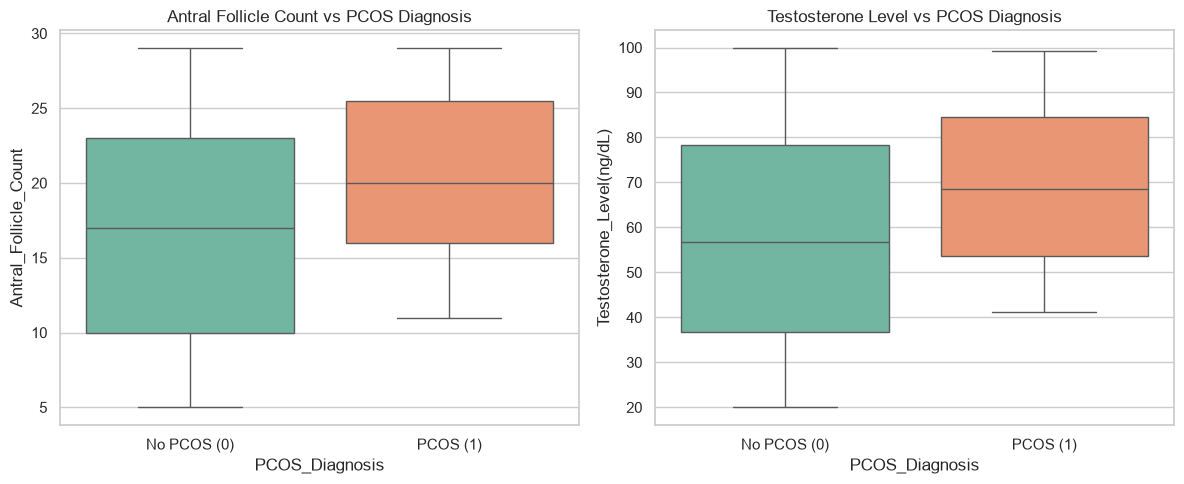

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# Create 2 side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Antral Follicle Count vs Diagnosis
sns.boxplot(x='PCOS_Diagnosis', y='Antral_Follicle_Count', data=df, ax=axes[0], hue='PCOS_Diagnosis', palette='Set2', legend=False)
axes[0].set_title('Antral Follicle Count vs PCOS Diagnosis')
axes[0].set_xticklabels(['No PCOS (0)', 'PCOS (1)'])

# Plot 2: Testosterone Level vs Diagnosis
sns.boxplot(x='PCOS_Diagnosis', y='Testosterone_Level(ng/dL)', data=df, ax=axes[1], hue='PCOS_Diagnosis', palette='Set2', legend=False)
axes[1].set_title('Testosterone Level vs PCOS Diagnosis')
axes[1].set_xticklabels(['No PCOS (0)', 'PCOS (1)'])

plt.tight_layout()
plt.show()

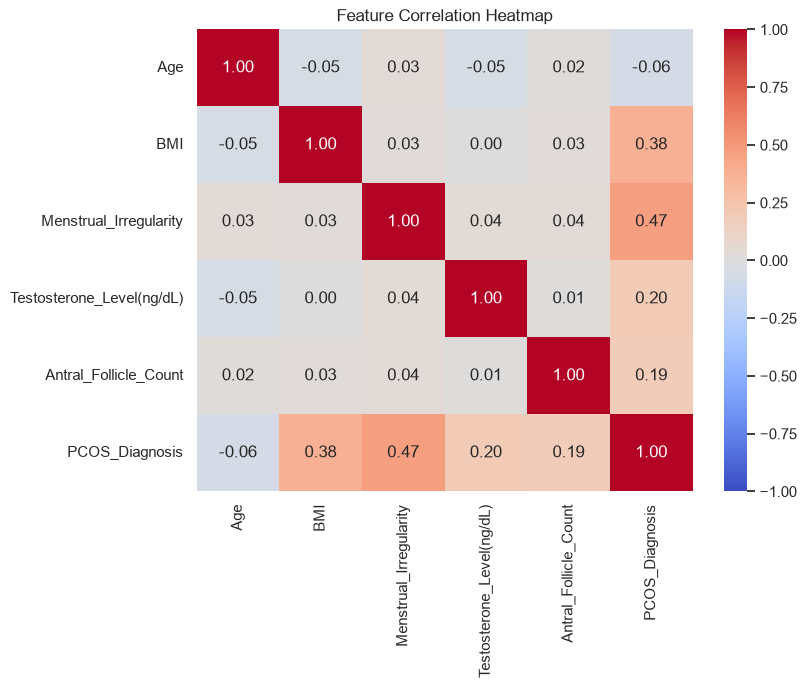

In [19]:
# Calculate correlation matrix for all numeric columns
plt.figure(figsize=(8, 6))

# Generate heatmap
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap')
plt.show()

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Separate feature inputs (X) from the target diagnosis (y)
X = df.drop(columns=['PCOS_Diagnosis'])
y = df['PCOS_Diagnosis']

# 2. Split data: 80% to train the model, 20% held back to test it
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Initialize and train the Random Forest Classifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# 4. Predict diagnosis on the hidden 20% test set
y_pred = model.predict(X_test)

# 5. Output overall performance metrics
print(f"Overall Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Detailed Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['No PCOS (0)', 'PCOS (1)']))

Overall Model Accuracy: 100.00%

Detailed Classification Report:

              precision    recall  f1-score   support

 No PCOS (0)       1.00      1.00      1.00       160
    PCOS (1)       1.00      1.00      1.00        40

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



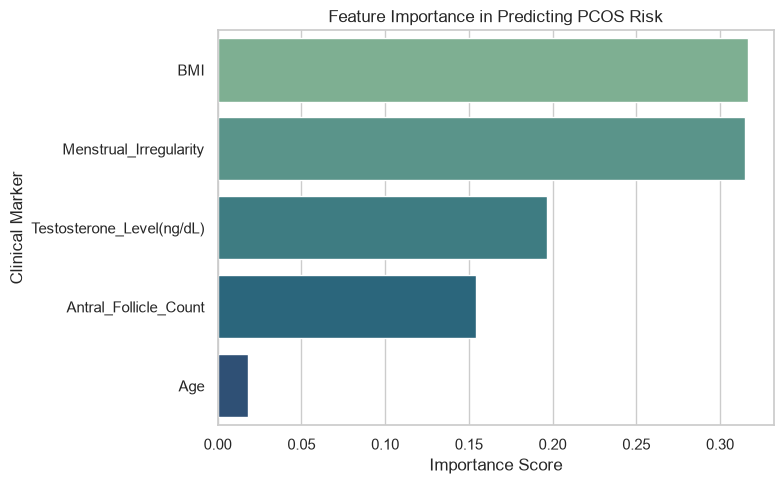

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extract feature importances
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=importance_df, hue='Feature', palette='crest', legend=False)
plt.title('Feature Importance in Predicting PCOS Risk')
plt.xlabel('Importance Score')
plt.ylabel('Clinical Marker')
plt.tight_layout()
plt.show()